# **Lab 08:** People Detection in Cloud Vision APIs (*AWS Rekognition*)

This notebook provides a practical **QuickStart** for people detection using cloud vision services from AWS Rekognition.

### **Environment and Prerequisites**

You will need:
- A Python 3 environment (e.g., Jupyter, VS Code, or similar).
- Cloud accounts for:
  - AWS (Rekognition).
- API keys or credentials for the provider.

This notebook assumes you have a local image file named `people.jpg` in the same directory as the notebook. You can replace it with any image path you prefer.

In [2]:
%pip install boto3
%pip install requests

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## **AWS Rekognition** – Person Detection via DetectLabels

![](aws_rekognition.png)

[AWS Rekognition](https://aws.amazon.com/pm/rekognition/?trk=6f58ae4e-0833-45f9-a21c-424b56761d19&sc_channel=ps&ef_id=CjwKCAjwnZfPBhAGEiwAzg-VzLT1PXUihhIuB8yZ-OIG4AW4O_IVmC6ET75JN54FjUcFytubvU-92hoCQOIQAvD_BwE:G:s&s_kwcid=AL!4422!3!798628455734!p!!g!!amazon%20image%20analysis!23600694654!193803764356&gad_campaignid=23600694654&gbraid=0AAAAADjHtp9YXOk8icgBSpUNHeUCp0rT-&gclid=CjwKCAjwnZfPBhAGEiwAzg-VzLT1PXUihhIuB8yZ-OIG4AW4O_IVmC6ET75JN54FjUcFytubvU-92hoCQOIQAvD_BwE) provides the `DetectLabels` API, which can detect the label "Person" and return bounding boxes for instances of that label in an image.

### AWS Setup

You need:
- An AWS account.
- IAM credentials with permissions to use Rekognition.
- AWS credentials configured via environment variables, AWS CLI, or configuration files.

The code below assumes your AWS credentials are already configured in your environment.

In [ ]:
import boto3
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# -----------------------------
# 1. AWS CREDENTIALS (NO SETUP REQUIRED)
# -----------------------------
AWS_ACCESS_KEY_ID = "<YOUR_AWS_ACCESS_KEY_ID>"
AWS_SECRET_ACCESS_KEY = "<YOUR_AWS_SECRET_ACCESS_KEY>"
AWS_REGION = "us-east-1"   # Cambia si usas otra región

rek_client = boto3.client(
    "rekognition",
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    region_name=AWS_REGION
)

# -----------------------------
# 2. LOAD IMAGE
# -----------------------------
image_path = "people.jpg"
image = Image.open(image_path)
img_w, img_h = image.size

with open(image_path, "rb") as f:
    image_bytes = f.read()

# -----------------------------
# 3. CALL AWS REKOGNITION
# -----------------------------
response = rek_client.detect_labels(
    Image={"Bytes": image_bytes},
    MaxLabels=50,
    MinConfidence=50.0
)

/Users/eugenio/Documents/Computer_Vision/.venv/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


AWS Rekognition detected 41 people


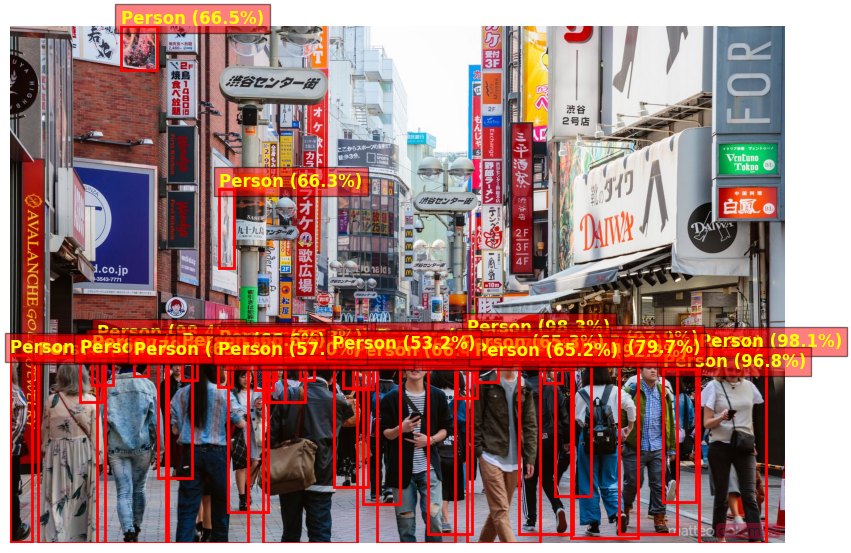

In [ ]:
# -----------------------------
# 4. EXTRACT PERSON DETECTIONS
# -----------------------------
persons = []
for label in response["Labels"]:
    if label["Name"].lower() == "person":
        for instance in label.get("Instances", []):
            bbox = instance["BoundingBox"]  # normalized
            persons.append({
                "confidence": instance.get("Confidence", label["Confidence"]),
                "bbox": [
                    bbox["Left"],
                    bbox["Top"],
                    bbox["Width"],
                    bbox["Height"]
                ]
            })

print("AWS Rekognition detected", len(persons), "people")

# -----------------------------
# 5. DRAW BOUNDING BOXES
# -----------------------------
fig, ax = plt.subplots(1, figsize=(10, 10))
ax.imshow(image)

for p in persons:
    left, top, width, height = p["bbox"]

    # Convert normalized → absolute pixel coords
    x1 = left * img_w
    y1 = top * img_h
    w = width * img_w
    h = height * img_h

    # Draw rectangle
    rect = patches.Rectangle(
        (x1, y1), w, h,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

    # Draw label text
    label = f"Person ({p['confidence']:.1f}%)"
    ax.text(
        x1, y1 - 5,
        label,
        color="yellow",
        fontsize=12,
        weight="bold",
        bbox=dict(facecolor="red", alpha=0.5)
    )

plt.axis("off")
plt.show()

### AWS Free Tier Notes

- After the first 12 months, all Rekognition usage is billed according to standard pricing.
- There is no perpetual free tier for people detection.
- This makes AWS Rekognition suitable for short-term experimentation and early-stage courses, but not for long-term free use beyond the first year.

## **Activity**

**Datasets:**  
[Access the dataset here](https://drive.google.com/drive/folders/1_dIEi3ydMg1GuzGIAzGjhwoJQpTiOaiT)  
You'll be in charge of one (1) video. Follow the alphabetical order that matches your video. E.g.:  
- `12d_5pm_c1.mp4` (Andi)
- `12d_5pm_c2.mp4` (Castro)
- ...  

##### **Step 1:** Object detection (person)
- With your assigned video, use *Amazon Rekognition* to detect people.

- **Note:** Don't process all frames (its expensive and unnecessary) ~$57USD. Instead, you can process 1 frame each 5sec (0.2FPS) ~$7. 
- *Hint:* You can convert your video to frames using `FFmpeg` (or similar) to extract an image each 5 sec: 

   ```python
   ffmpeg -i input.mp4 -vf fps=0.2 frames/output.jpg
   ```

- Don't forget to process (crop) each frame after receiving the `response` variable from AWS Rekognition.

##### **Step 2:** Image classification (genre and age range)

- With the cropped person images, use Roboflow to tag the following labels (at least 20 labels per age class). If the same person is detected multiple times, you can select one image for tagging.

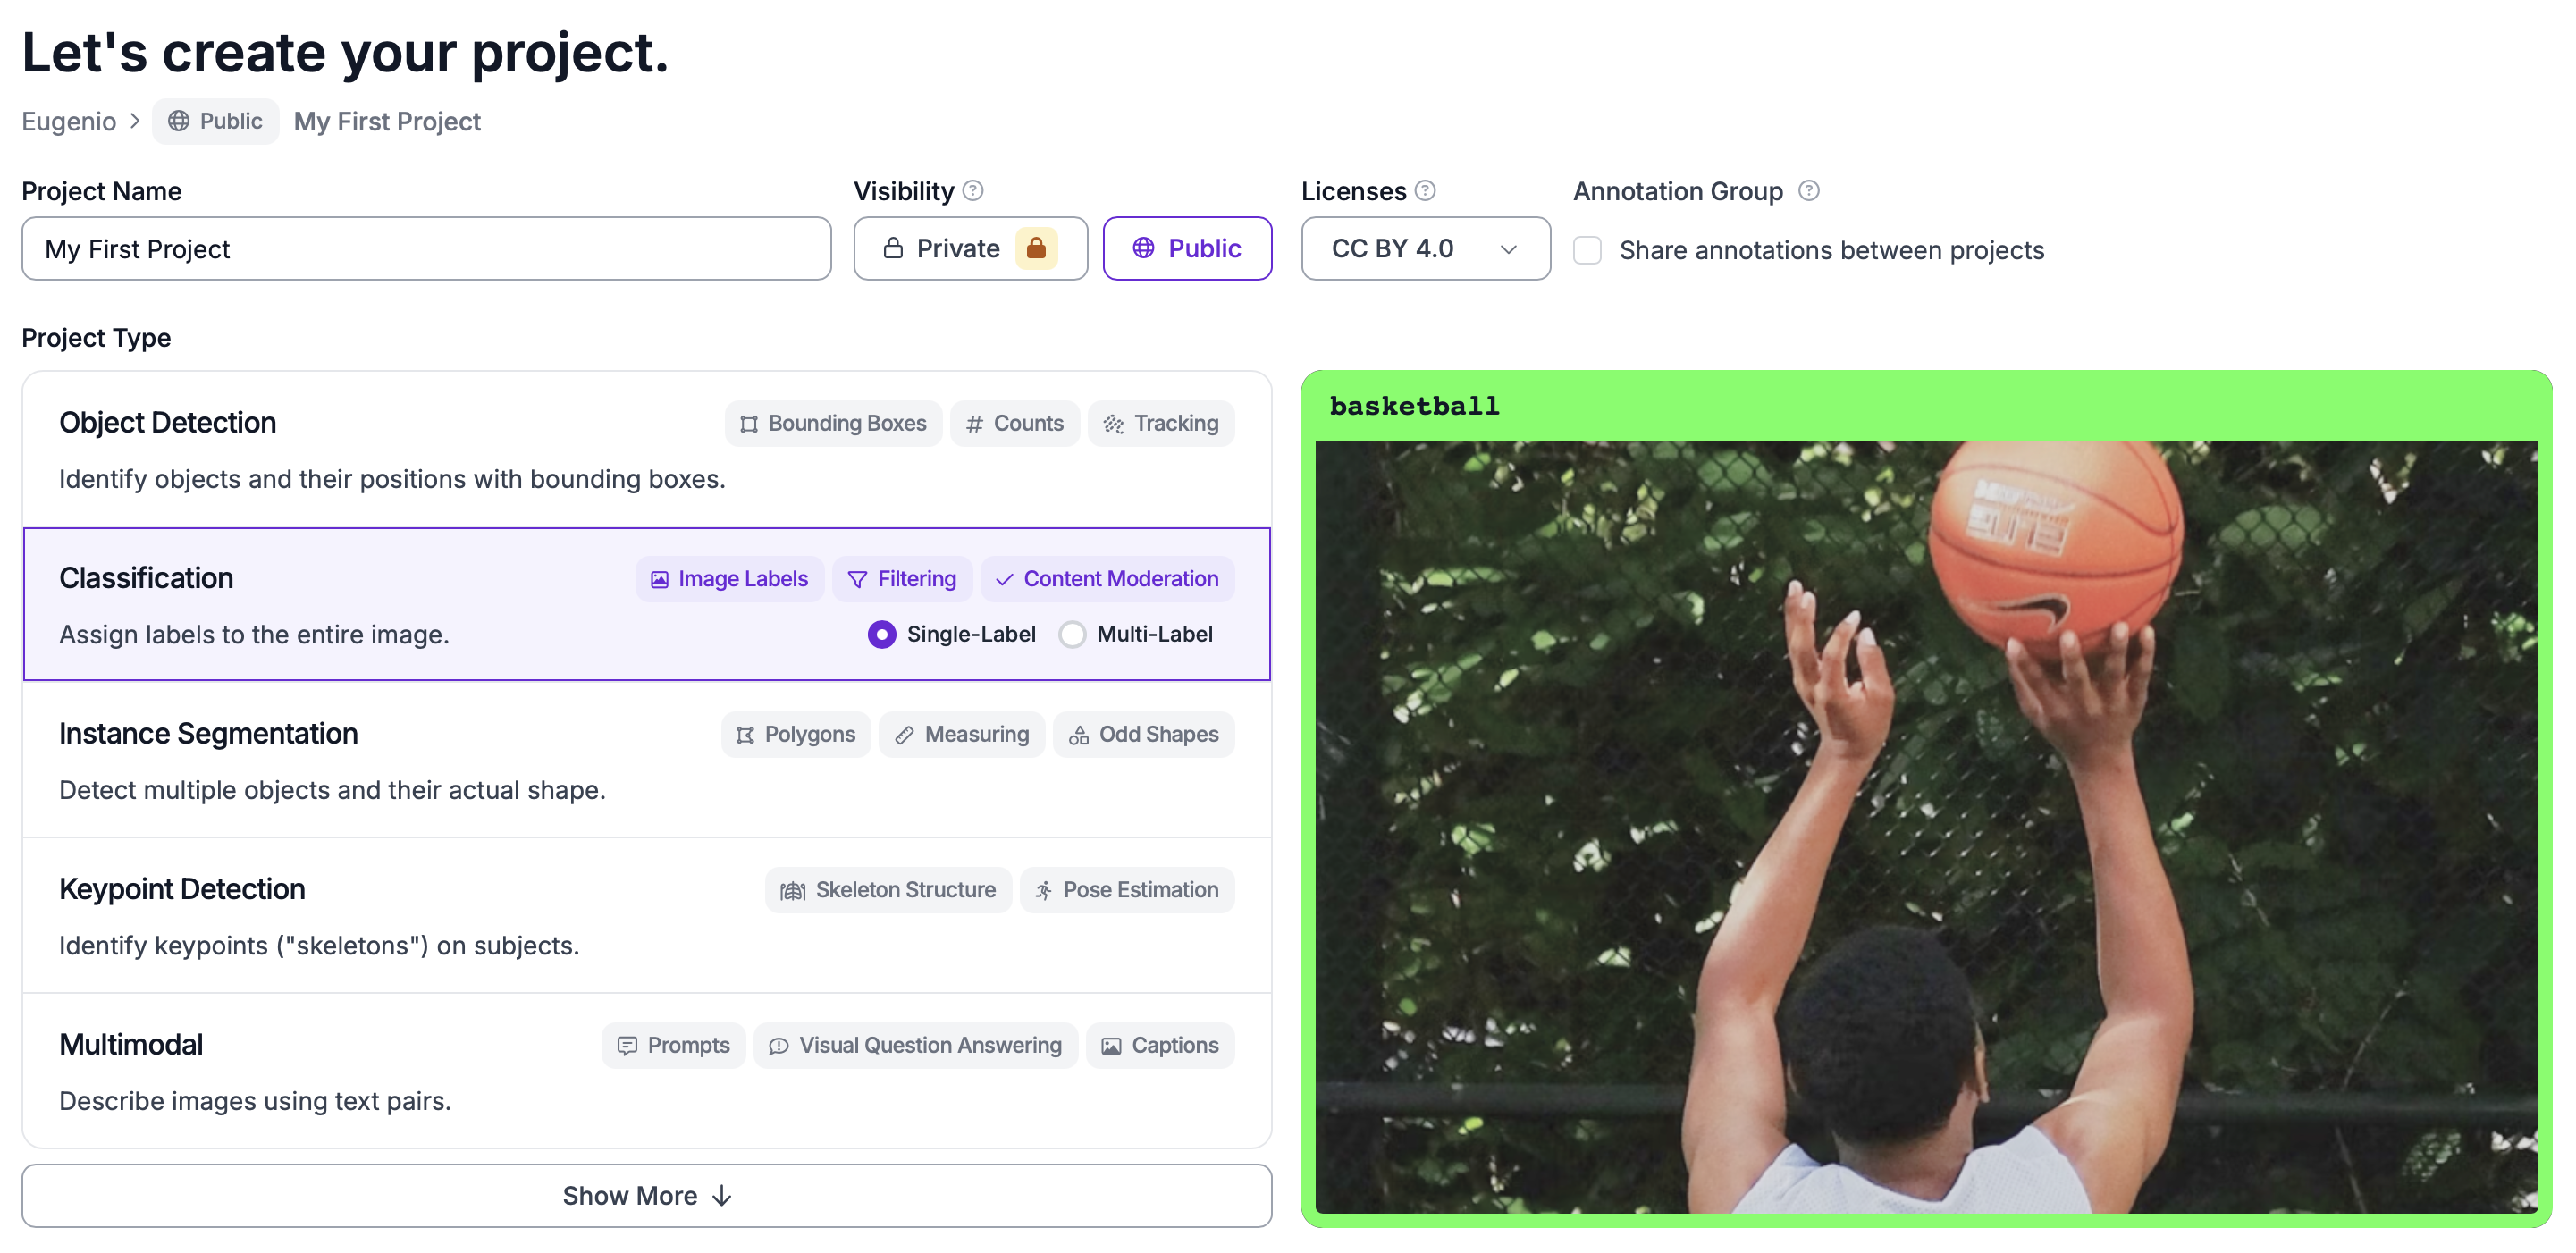

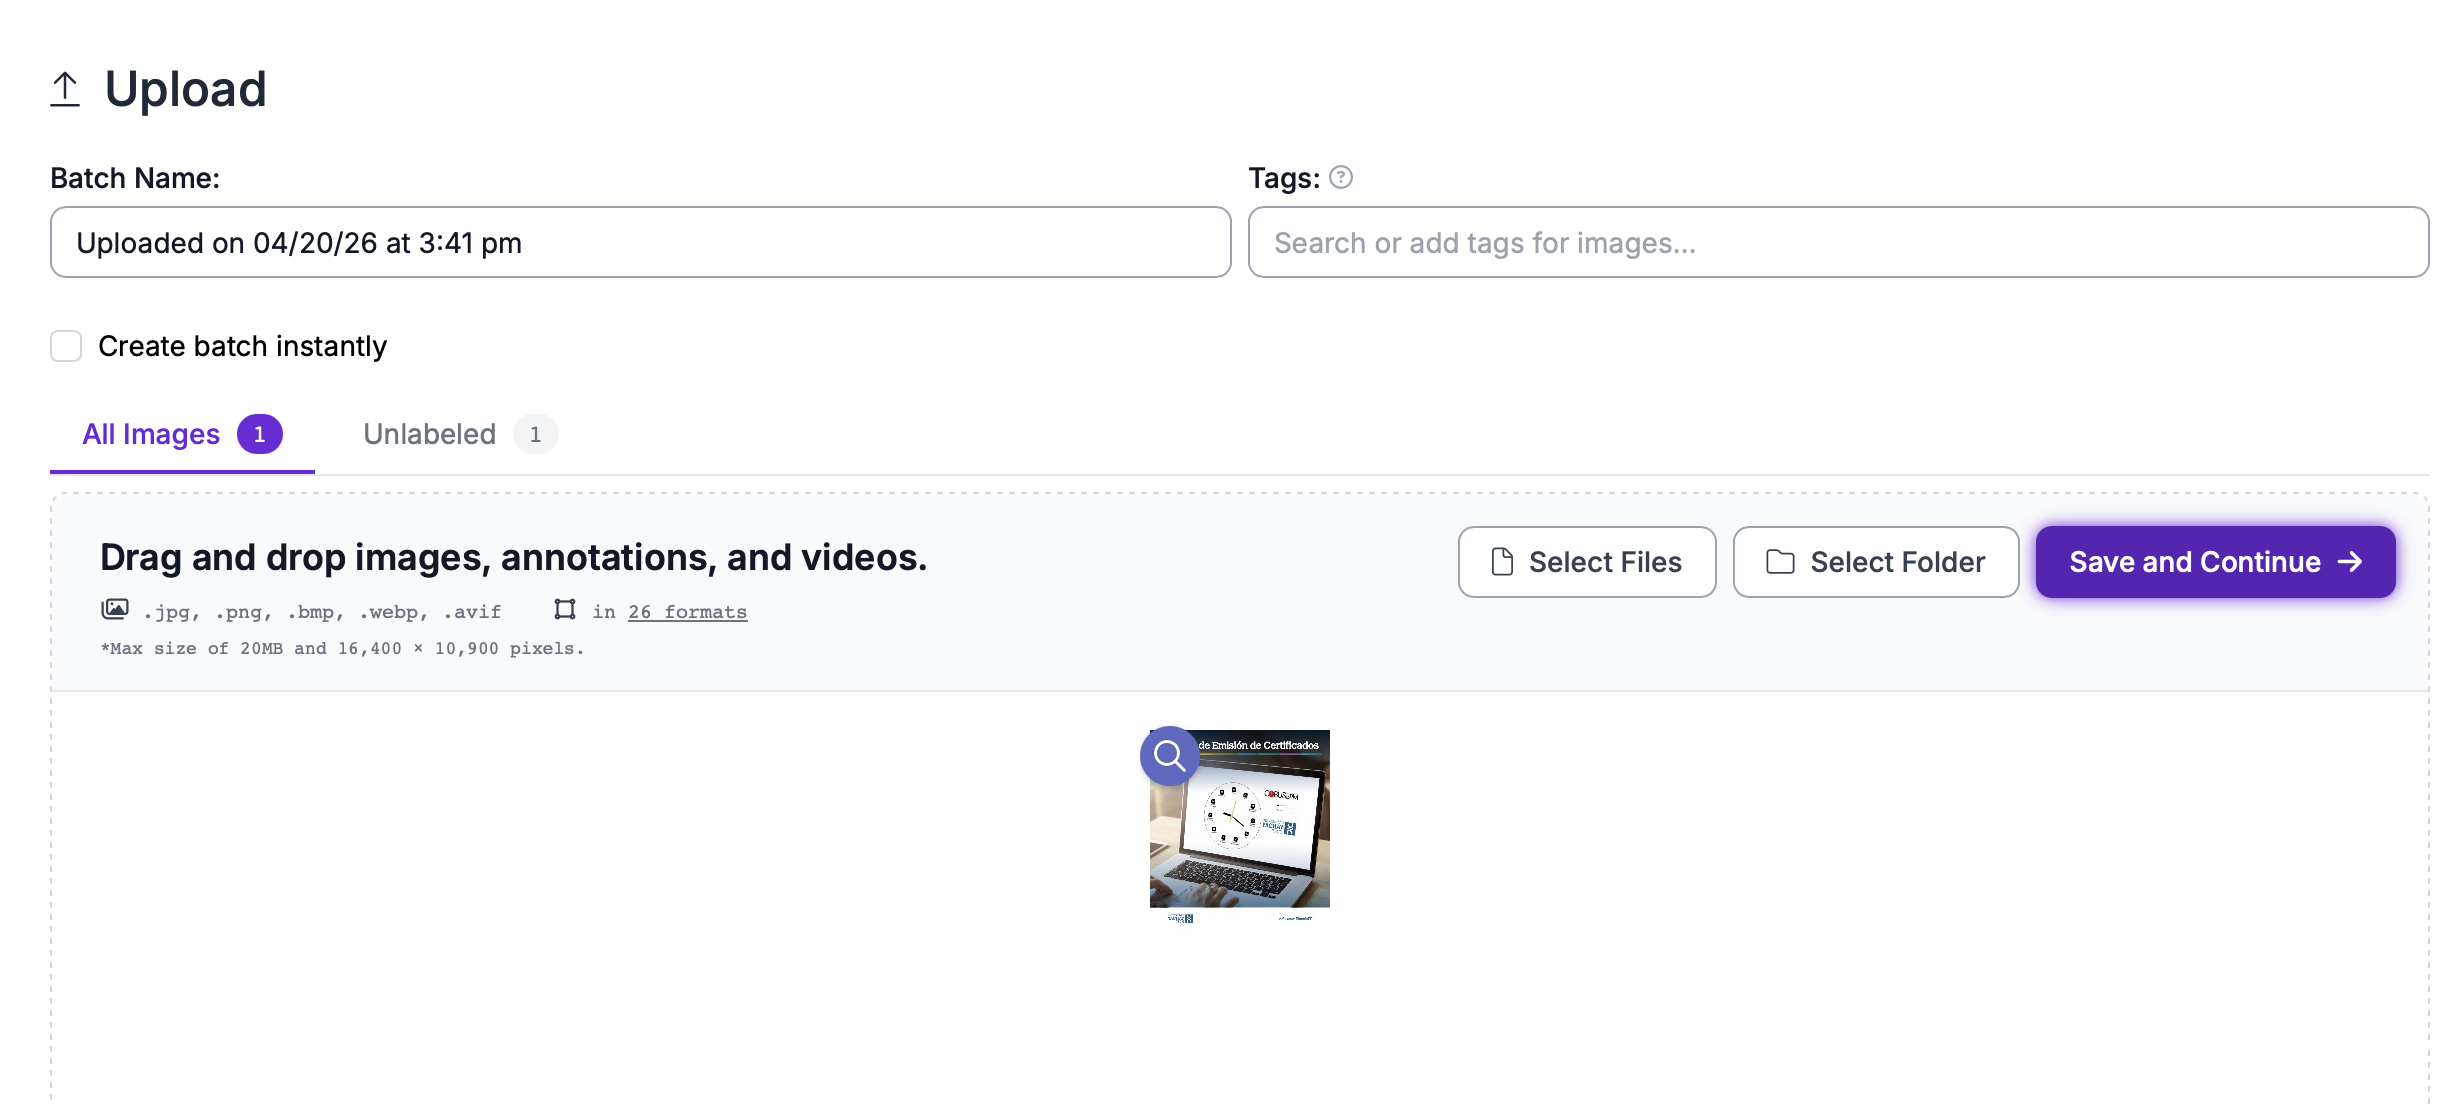

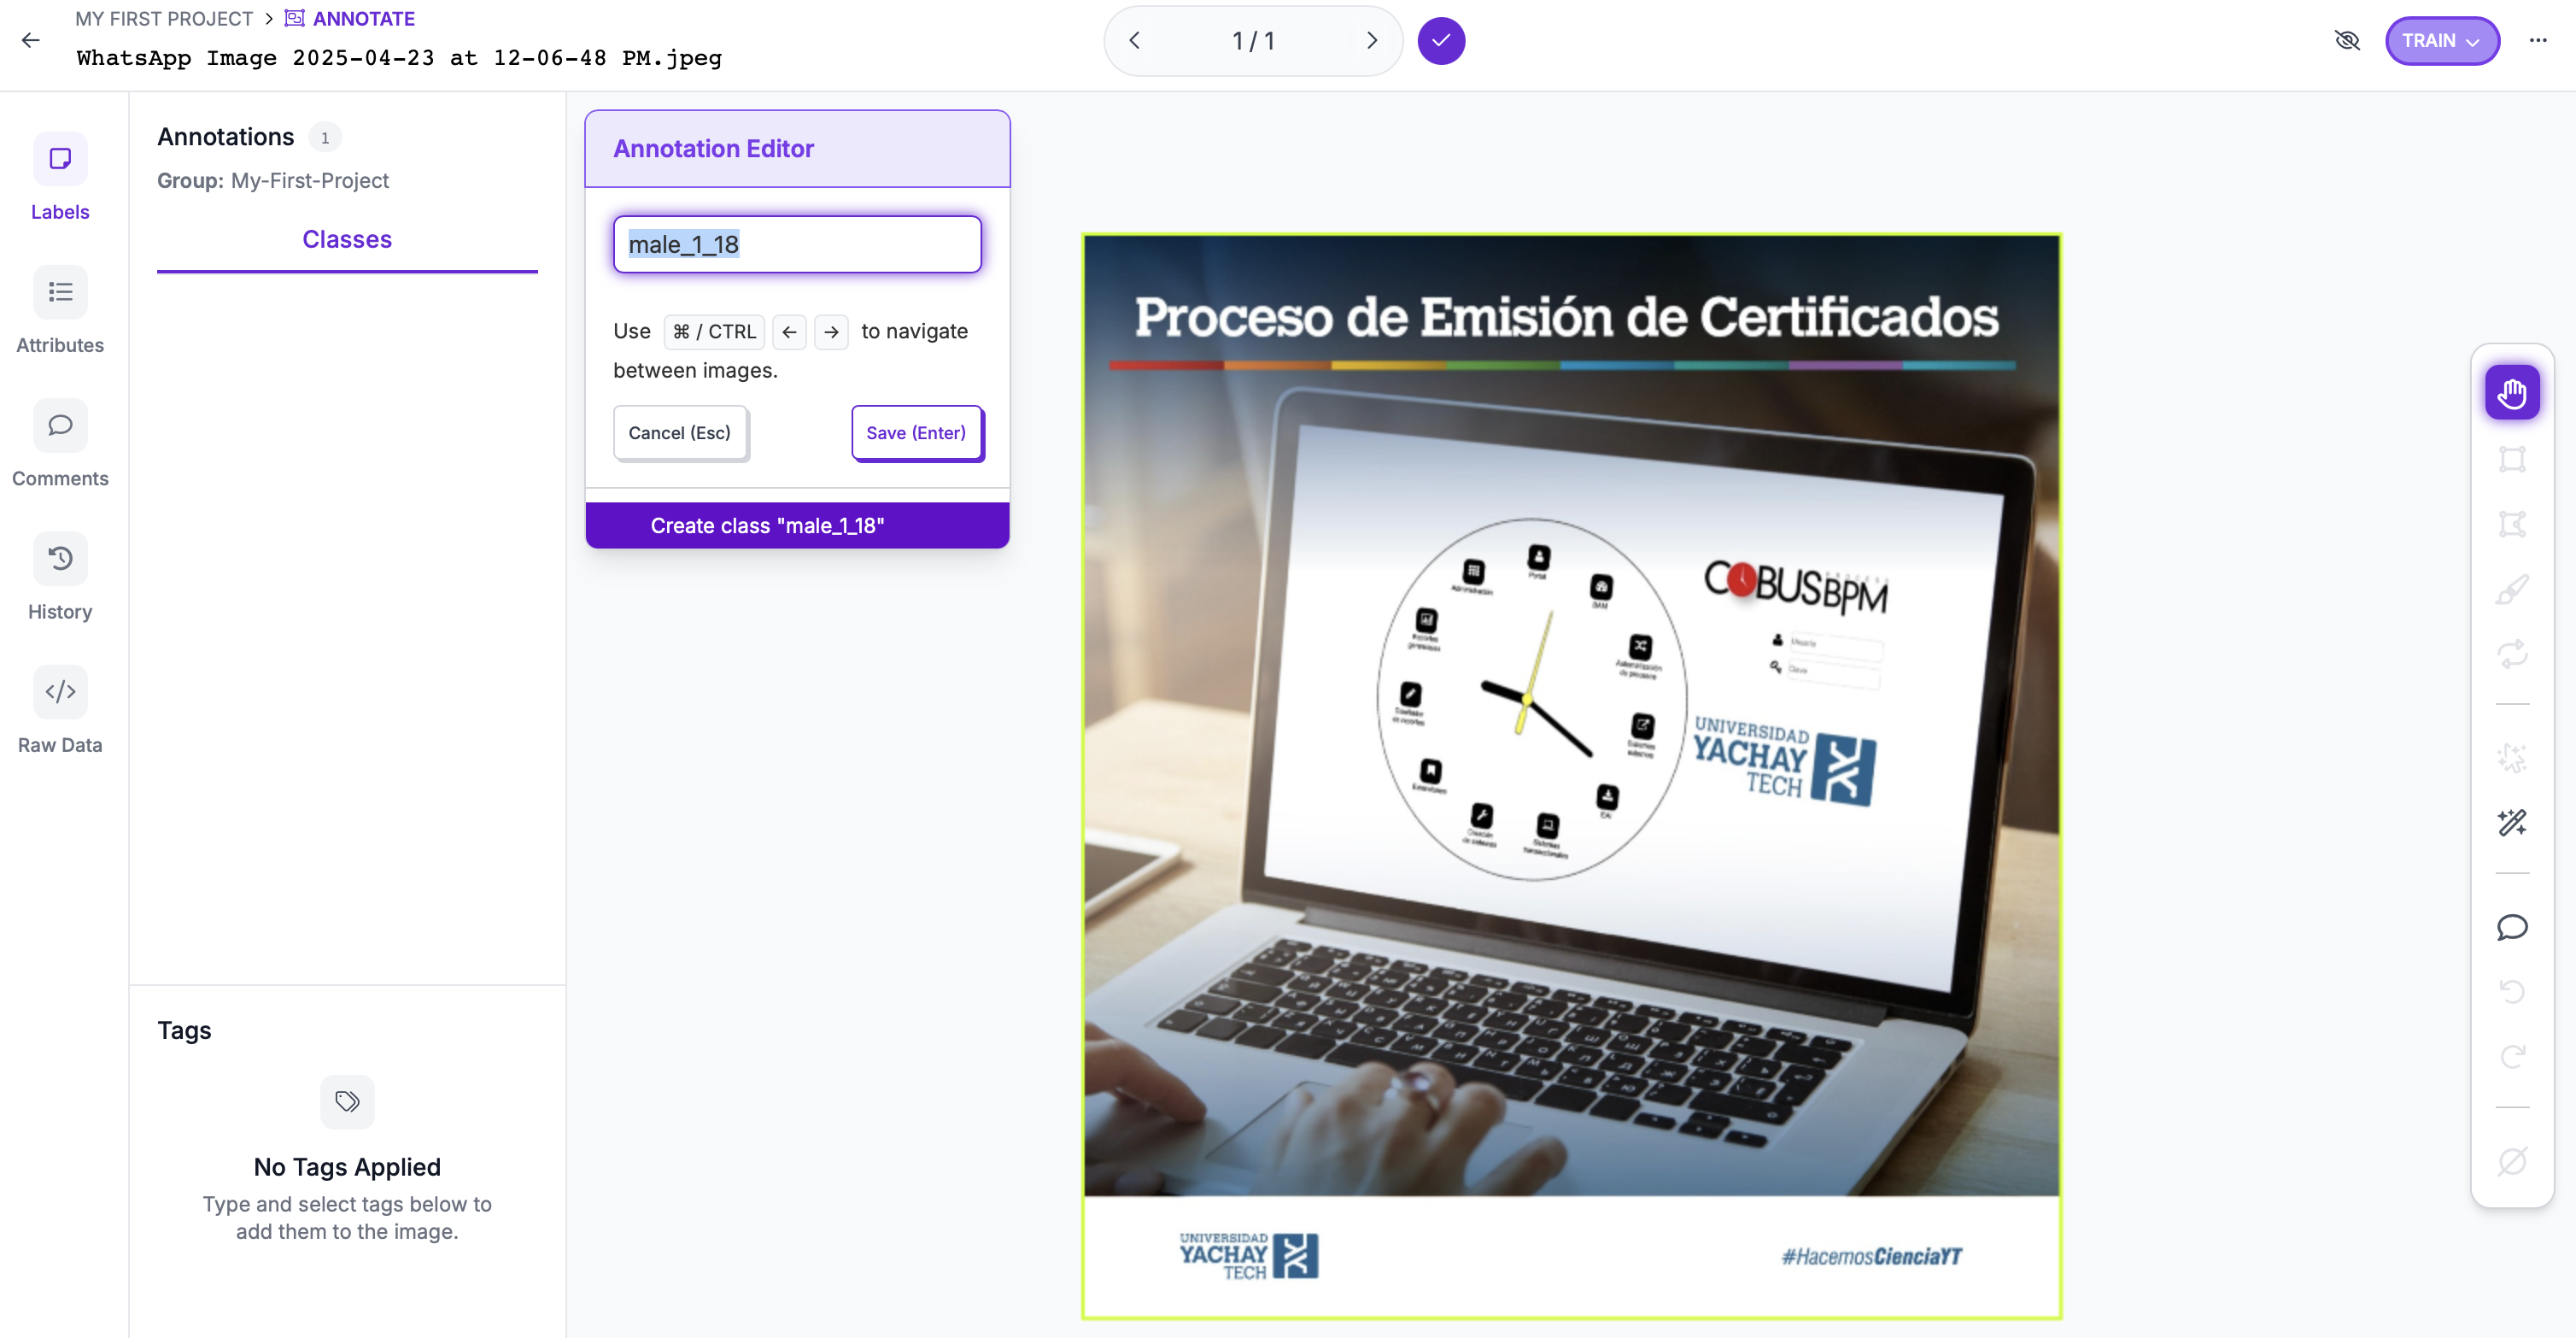

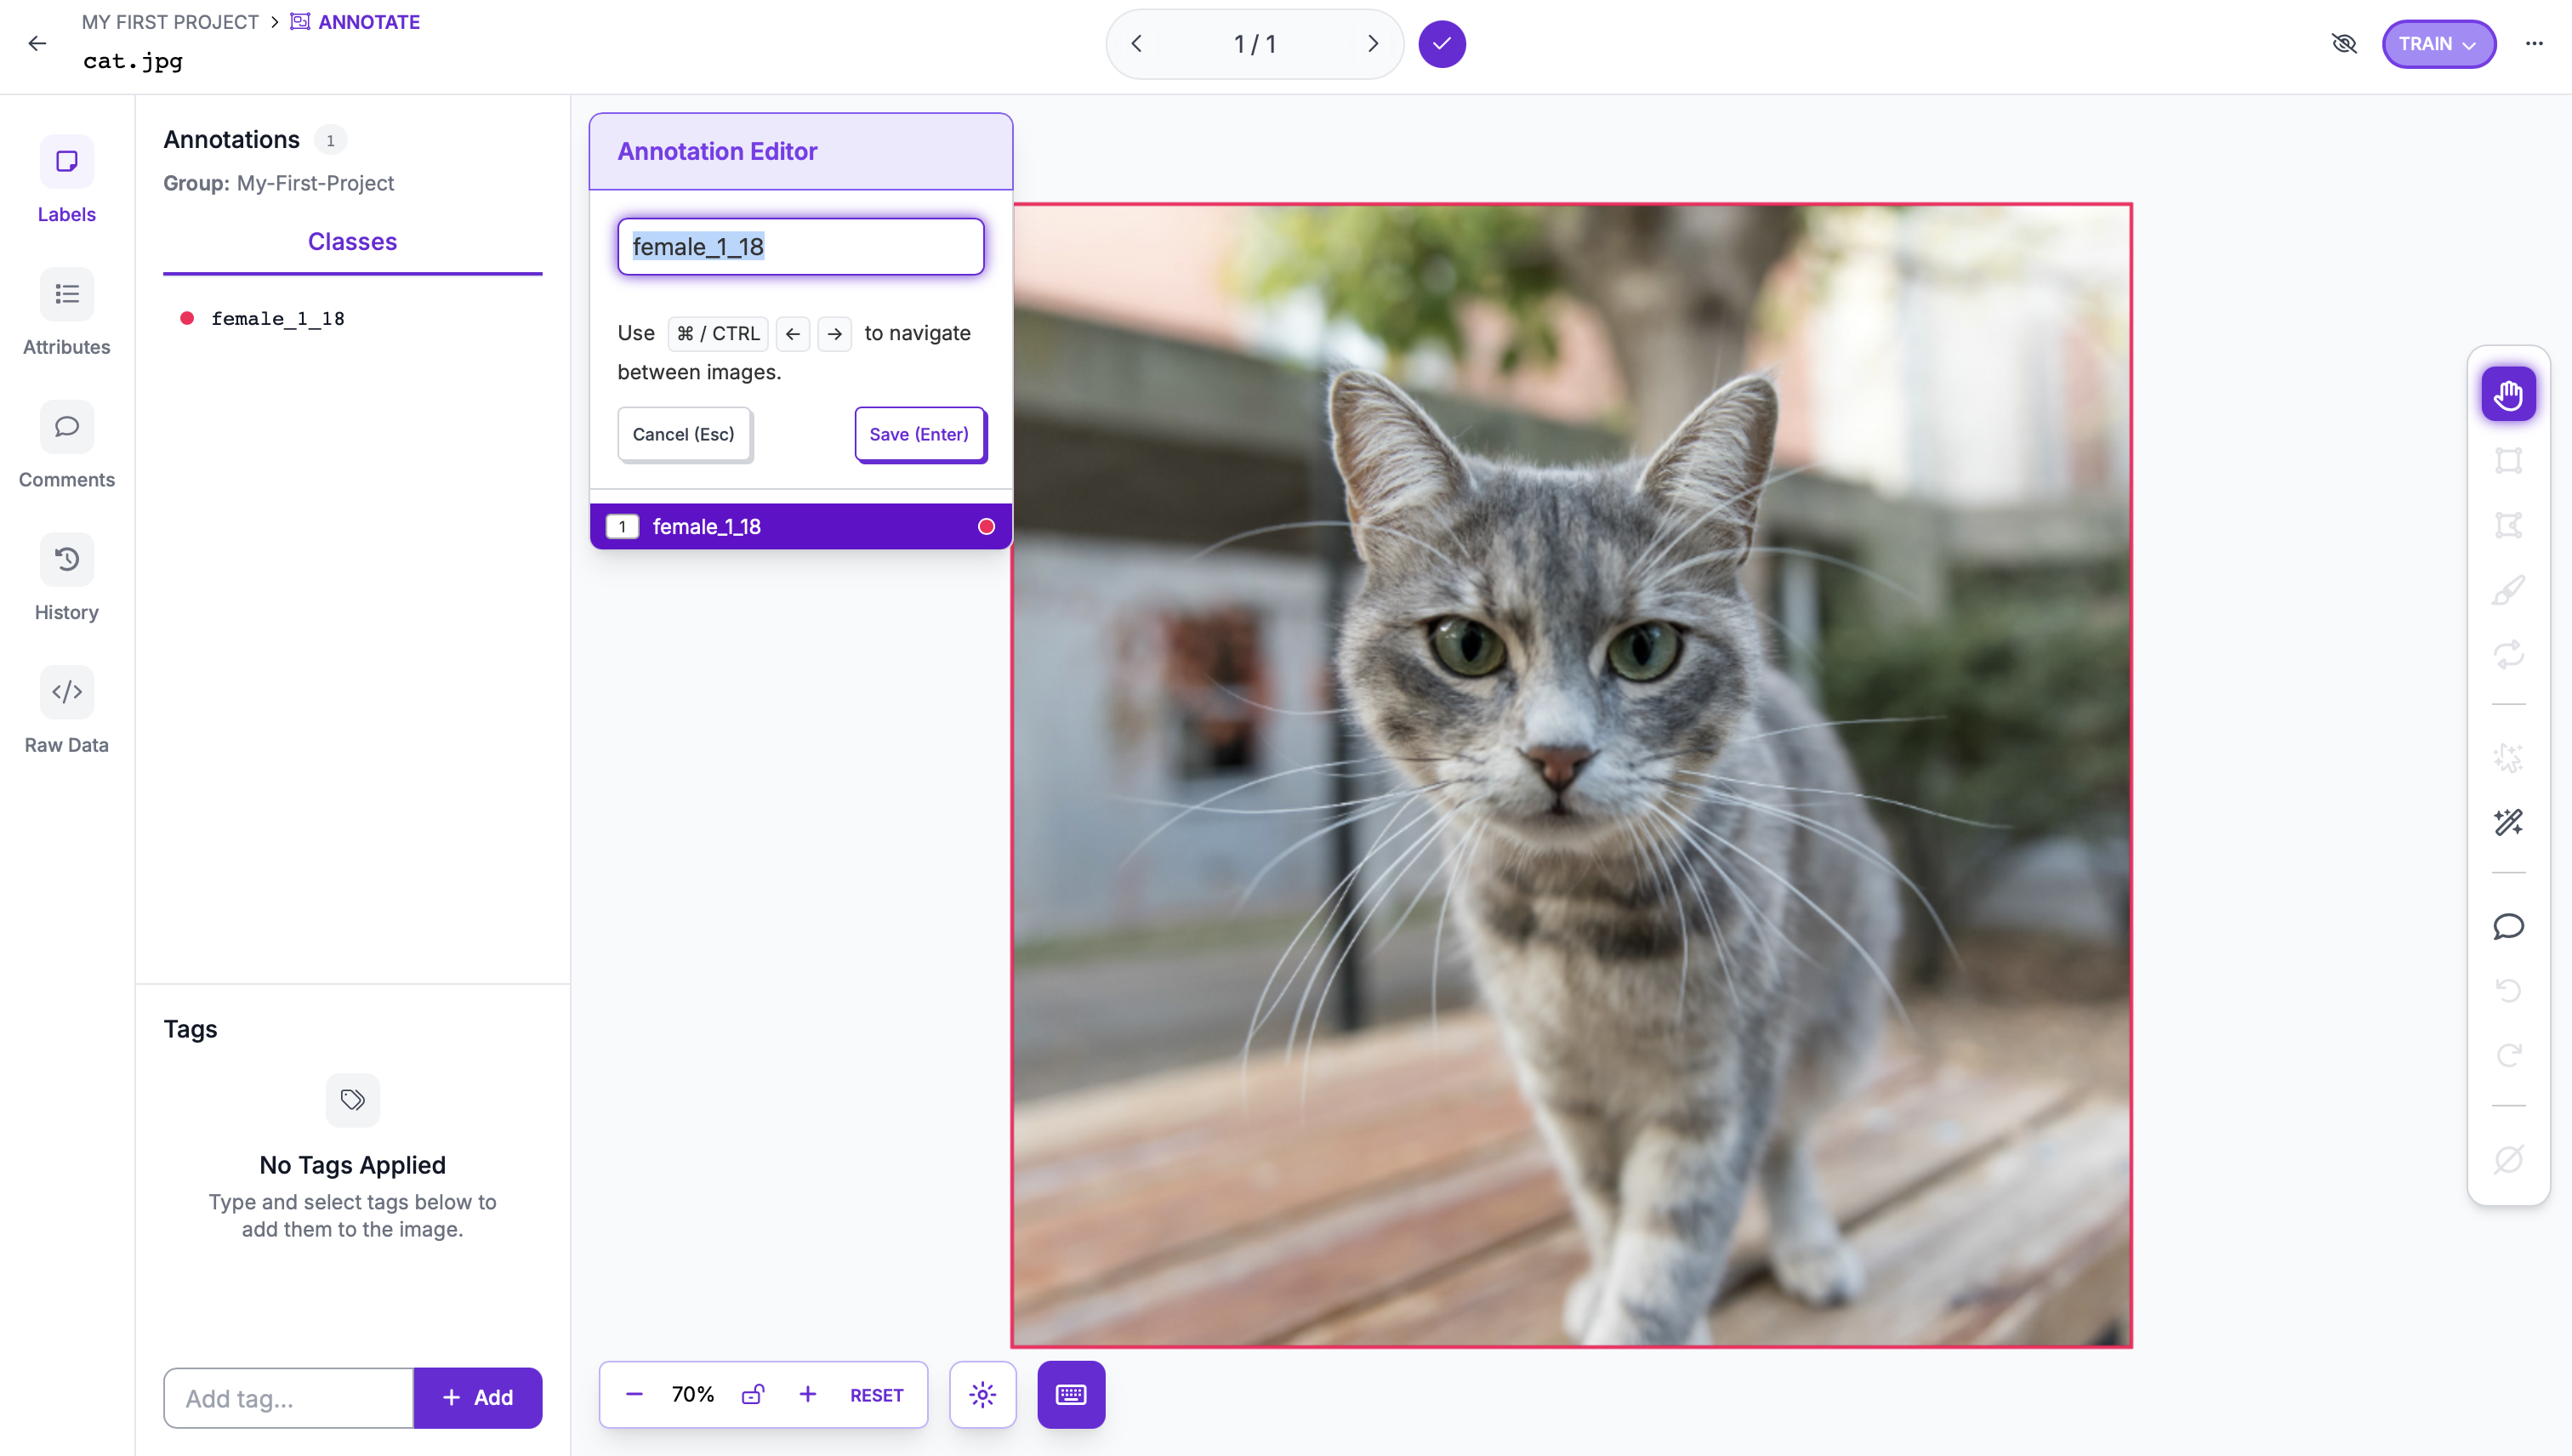

The fixed classes to tag are:

   - `male_1_18`
   - `female_1_18`
   - `male_19_50`
   - `female_19_50`
   - `male_gt_50`
   - `female_gt_50`

- Retrain a **local YOLO model** (*or an equivalent, e.g., PeopleNet, DashCamNet, NanoOWL, SSD-Mobilenet, etc.*) to detect the classes on the video and print the results (classification metrics, number of detected labels in your video).

Create a new folder with the video name and upload the labels of your project to the dataset [url](https://drive.google.com/drive/folders/1_dIEi3ydMg1GuzGIAzGjhwoJQpTiOaiT). 

### **Grading Rubric:**

| **Detail** | **Score (10pts)** |  
|---|---|  
| AWS Rekognition detection | 2pts |  
| Image Labeling | 4pts |  
| Model training/retraining | 2pts |  
| Presentation of results | 2pts |  

---

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>